<a href="https://colab.research.google.com/github/zainazeem41472/Rice-Leaf-Disease-Classification/blob/main/hybridmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 120

TRAIN_DIR = "/content/drive/MyDrive/RiceLeafDisease12classes/train"
VAL_DIR   = "/content/drive/MyDrive/RiceLeafDisease12classes/validation"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_names)

Found 11996 images belonging to 12 classes.
Found 1413 images belonging to 12 classes.


In [ ]:
def residual_block(x, filters):

    shortcut = Conv2D(filters, 1, padding="same")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = LeakyReLU(0.1)(x)

    return x

In [ ]:
def dense_block(x, growth_rate=32):

    y = Conv2D(growth_rate, 3, padding="same", activation="relu")(x)
    x = Concatenate()([x, y])

    y = Conv2D(growth_rate, 3, padding="same", activation="relu")(x)
    x = Concatenate()([x, y])

    return x

In [ ]:
def se_block(x):

    filters = x.shape[-1]

    se = GlobalAveragePooling2D()(x)
    se = Dense(filters//4, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)

    se = Reshape((1,1,filters))(se)

    return Multiply()([x, se])

In [ ]:
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(64, 3, padding="same")(inputs)
x = BatchNormalization()(x)
x = LeakyReLU(0.1)(x)

# Block 1
x = residual_block(x, 64)
x = MaxPooling2D()(x)

# Block 2
x = dense_block(x)
x = se_block(x)
x = MaxPooling2D()(x)

# Block 3
x = residual_block(x, 128)
x = MaxPooling2D()(x)

# Block 4
x = dense_block(x)
x = se_block(x)
x = MaxPooling2D()(x)

# Block 5
x = residual_block(x, 256)

# Head
x = GlobalAveragePooling2D()(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = LeakyReLU(0.1)(x)
x = Dropout(0.5)(x)

x = Dense(256)(x)
x = LeakyReLU(0.1)(x)
x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

In [ ]:
optimizer = AdamW(learning_rate=0.0001, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.3),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 5191s 14s/step - accuracy: 0.6130 - loss: 1.4792 - val_accuracy: 0.1451 - val_loss: 3.2050 - learning_rate: 1.0000e-04
Epoch 2/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 265s 706ms/step - accuracy: 0.7579 - loss: 1.1503 - val_accuracy: 0.8209 - val_loss: 0.9949 - learning_rate: 1.0000e-04
Epoch 3/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 263s 701ms/step - accuracy: 0.8192 - loss: 1.0182 - val_accuracy: 0.8294 - val_loss: 0.9457 - learning_rate: 1.0000e-04
Epoch 4/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 268s 714ms/step - accuracy: 0.8584 - loss: 0.9254 - val_accuracy: 0.8648 - val_loss: 0.9203 - learning_rate: 1.0000e-04
Epoch 5/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 265s 706ms/step - accuracy: 0.8850 - loss: 0.8712 - val_accuracy: 0.8386 - val_loss: 1.0234 - learning_rate: 1.0000e-04
Epoch 6/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 268s 712ms/step - accuracy: 0.9001 - loss: 0.8369 - val_accuracy: 0.9200 - val_loss: 0.7917 - learning_rate: 1.0000e-04
Epoch 7/120
375/375 ━━━━━━━━━━━━━━━

In [ ]:
model.save("/content/drive/MyDrive/final_hybrid_model.h5")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hispa.jfif to hispa.jfif


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


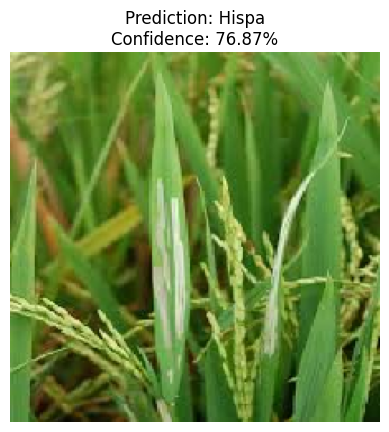

Predicted Class: Hispa
Confidence: 76.87%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

for img_name in uploaded.keys():

    img = image.load_img(img_name, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred = model.predict(val_generator)

y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

print("Accuracy:", accuracy_score(y_true, y_pred) * 100)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 296ms/step
Accuracy: 99.00920028308563

Classification Report:

                       precision    recall  f1-score   support

                Hispa       1.00      1.00      1.00        88
   Ragged Stunt Virus       1.00      1.00      1.00        88
           Sheath Rot       1.00      1.00      1.00        81
             Stem Rot       1.00      1.00      1.00        88
               Tungro       1.00      1.00      1.00        88
bacterial_leaf_blight       1.00      1.00      1.00        88
           brown_spot       0.98      0.90      0.93        88
              healthy       0.94      1.00      0.97        88
      irrelevant_pics       1.00      1.00      1.00       452
           leaf_blast       0.93      0.94      0.94        88
           leaf_scald       1.00      1.00      1.00        88
    narrow_brown_spot       1.00      1.00      1.00        88

             accuracy                           0.99      1413
            macro avg

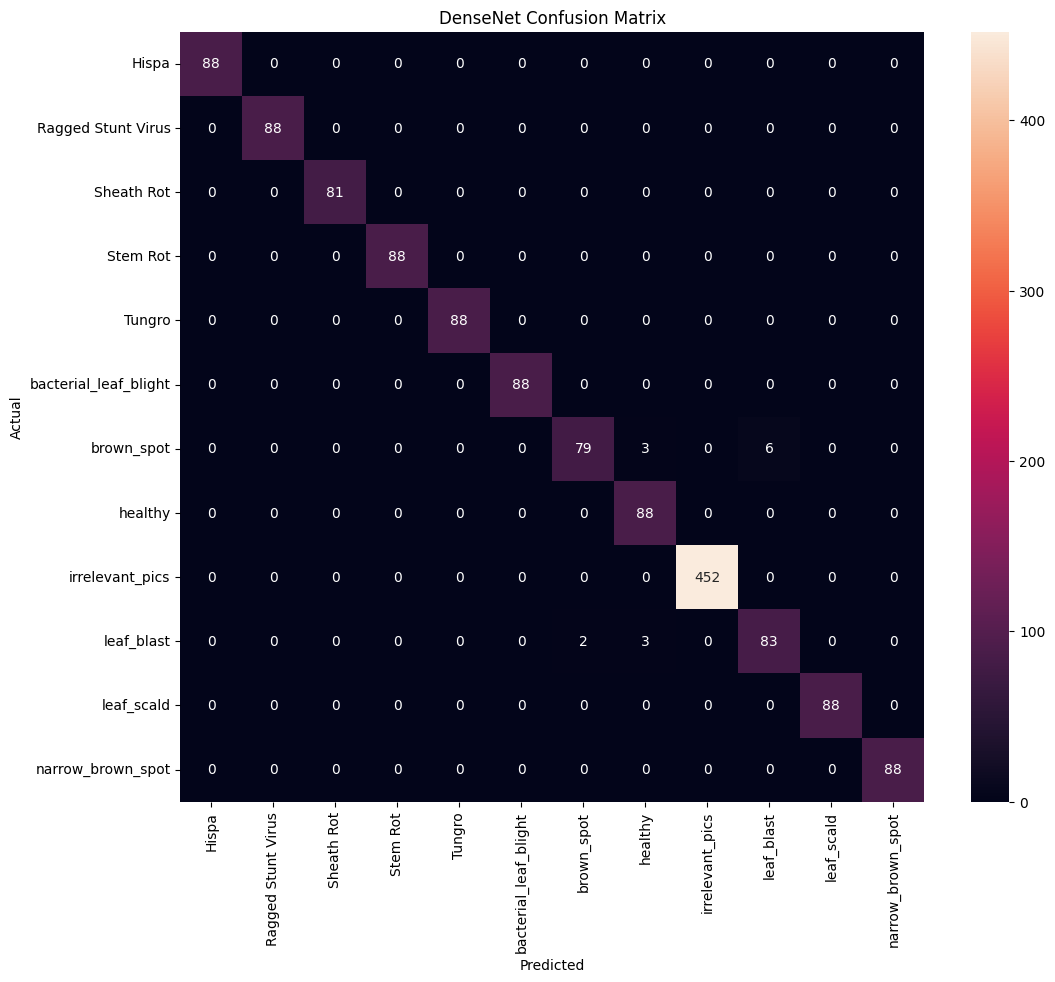

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet Confusion Matrix")
plt.show()